Machine learning project: Kmeans clustering for customer segmentation

This project uses the Online Retail II dataset from UC Irvine ML repository, found here: https://archive.ics.uci.edu/dataset/502/online+retail+ii

The objective of the project is segment customers based on RFM analysis using Kmeans clustering to understand customer behaviour and suggest actions or strategies based on the findings.
The project consists of data exploration, cleaning, and pre-processing, followed by feature engineering, modelling, and result interpretation and suggesting strategies and actions. It is important to note that due to a high number of outliers found during the analysis, modeling is performed separately for outliers and normal data. Each step of the project is described and documented.


In [ ]:
import openpyxl as px
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, skew, zscore
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import sklearn as sk
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1" 

pd.options.display.float_format = '{:20.2f}'.format

Data exploration

In [2]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name=0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [3]:
print("\nDataframe information:")
print(df.info())


Dataframe information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None


In [4]:
print("\nDataframe description:")
print(df.describe())


Dataframe description:
                  Quantity                    InvoiceDate  \
count            525461.00                         525461   
mean                 10.34  2010-06-28 11:37:36.845017856   
min               -9600.00            2009-12-01 07:45:00   
25%                   1.00            2010-03-21 12:20:00   
50%                   3.00            2010-07-06 09:51:00   
75%                  10.00            2010-10-15 12:45:00   
max               19152.00            2010-12-09 20:01:00   
std                 107.42                            NaN   

                     Price          Customer ID  
count            525461.00            417534.00  
mean                  4.69             15360.65  
min              -53594.36             12346.00  
25%                   1.25             13983.00  
50%                   2.10             15311.00  
75%                   4.21             16799.00  
max               25111.09             18287.00  
std                 146.13

In [5]:
print("\nDataframe missing values:")
print(df.isnull().sum())


Dataframe missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [6]:
print("\nDescription of object columns:")
print(df.describe(include=['object']))


Description of object columns:
        Invoice StockCode                         Description         Country
count    525461    525461                              522533          525461
unique    28816      4632                                4681              40
top      537434    85123A  WHITE HANGING HEART T-LIGHT HOLDER  United Kingdom
freq        675      3516                                3549          485852


Based on the information, there are a lot of missing values in Customer ID, and negative values in Quantity and Price. Also, based on the info description in the website, the Invoice column has values that start with C, meaning cancelation. Furhter analysis is required to evaluate the data.

In [ ]:
# Check rows where quantity is negative to search for patterns
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


It would also be useful to check if values in Invoice, whether they contain C or not, have the same length

In [ ]:
df['Invoice'] = df['Invoice'].astype(str)
# Using RegEx patterns to search for values that don't follow the specified 6 digit pattern
df[df['Invoice'].str.match('^\\d{6}$') == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


Now, to check if C is the only letter in the Invoice column data:

In [ ]:
# Create a list of unique letters in the Invoice column
df['Invoice'].str.replace('[0-9]', '', regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [ ]:
# To further check the rows that contain a  different invoice letter:
df[df['Invoice'].str.startswith('A') == True]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


Only 3 records have an A, and appear to be accounting records, so they can be dropped.

Now, check if the values in StockCode are all 5 digit numbers as specified in the dataset description from the website, as the data type of the column is object

In [11]:
df['StockCode'] = df['StockCode'].astype(str)
df[df['StockCode'].str.match('^\\d{5}$') == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.00,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.00,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.00,United Kingdom
...,...,...,...,...,...,...,...,...
525387,538170,84029E,RED WOOLLY HOTTIE WHITE HEART.,2,2010-12-09 19:32:00,3.75,13969.00,United Kingdom
525388,538170,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,2,2010-12-09 19:32:00,3.75,13969.00,United Kingdom
525389,538170,85232B,SET OF 3 BABUSHKA STACKING TINS,2,2010-12-09 19:32:00,4.95,13969.00,United Kingdom
525435,538171,47591D,PINK FAIRY CAKE CHILDRENS APRON,1,2010-12-09 20:01:00,1.95,17530.00,United Kingdom


As the data description doesn't mention letters in the StockCode values but they seem as real transactions, the assumption that they are valid is made.

To further filter and see if there are any more StockCodes that have a different pattern:

In [ ]:
df[(df['StockCode'].str.match('^\\d{5}$') == False) & 
   (df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$') == False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.00,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.00,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.00,Belgium
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.00,Germany
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299.00,United Kingdom
...,...,...,...,...,...,...,...,...
524776,538147,M,Manual,1,2010-12-09 16:11:00,15.00,13090.00,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


See the unique values of StockCode that don't follow the pattern:

In [13]:
df[(df['StockCode'].str.match('^\\d{5}$') == False) & 
   (df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [ ]:
# Analysing the unique values of StockCode that don't follow the pattern, focusing on the PAD code:
df[df['StockCode'].str.match('^PADS$')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.00,16705.00,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.00,13583.00,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.00,17350.00,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.00,13408.00,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.00,13408.00,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.00,15182.00,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.00,13765.00,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.00,14459.00,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.00,14857.00,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.00,12671.00,Germany


After detailed analysis of each stock code, the following summary shows the findings and suggestions:
Stock codes summary

1) POST: This appears to be a valid StockCode, possibly indicating a postal service or related item.

2) D: Stands for discount, althought transactions seem valid, they won't be useful for clustering.

3) DCGS0058: Code refering to a specific item (MISO PRETTY GUM)

4) DOT: Refering to dotcom postage, valid but not useful as cutomer ID is missing

5) M: Code refering to manual. Mostly full transaction records but likely not useful further for clustering.

6) DCGS0004: 4 rows refering to a specific item. Drop these rows as they are not useful for clustering.

7) DCGS0076: Another product specific code, dropping is suggested due to missing customer IDs

8) C2: Code refering to carriage, valid transactions but not useful.

9) BANK CHARGES: These records are not relevant and should be dropped

10) DCGS0003: Product specific code, dropping is suggested due to missing customer IDs

11) TEST001: Code for a test product, not useful as they are tests

12) gift_0001_80: Code refering to gitf vouchers, not useful.

13) DCGS0072: Product specific code with only 3 rows, dropping is suggested

14) gift_0001_20: Code refering to gift vouchers, not useful.

15) DCGS0044: Product specific code with only 1 row, dropping is suggested

16) TEST002: Code for a test product, not useful as they are tests

17) gift_0001_10: Code refering to gift vouchers, not useful.

18) gift_0001_50: Code refering to gift vouchers, not useful.

19) DCGS0066N: Product specific code with null values, dropping is suggested

20) gift_0001_30: Code refering to gift vouchers, not useful.

21) PADS: Code refering to cushion pads, valid and likely useful for clustering.

22) ADJUST: Adjustment records, not useful.

23) gift_0001_40: Code refering to gift vouchers, not useful.

24) gift_0001_60: Code refering to gift vouchers, not useful.

25) gift_0001_70: Code refering to gift vouchers, not useful.

26) gift_0001_90: Code refering to gift vouchers, not useful.

27) DCGSSGIRL: Product specific code, invalid due to missing customer IDs, dropping is suggested.

28) DCGS0006: Product specific code with invalid records, dropping is suggested

29) DCGS0016: Product specific code with invalid records, dropping is suggested

30) DCGS0027: Product specific code with invalid records, dropping is suggested

31) DCGS0036: Product specific code with invalid records, dropping is suggested

32) DCGS0039: Product specific code with invalid records, dropping is suggested

33) DCGS0060: Product specific code with invalid records, dropping is suggested

34) DCGS0056: Product specific code with invalid records, dropping is suggested

35) DCGS0059: Product specific code with invalid records, dropping is suggested

36) GIFT: Single row for a git code or voucher, irrelevant.

37) DCGSLBOY: Single row for a product with incomplete record, dropping is suggested.

38) m: Another code for manuals, irrelevant.

39) DCGS0053: Product specific code with invalid records, dropping is suggested

40) DCGS0062: Product specific code with invalid records, dropping is suggested

41) DCGS0037: Product specific code with invalid records, dropping is suggested

42) DCGSSBOY: Product specific code with invalid records, dropping is suggested.

43) DCGSLGIRL: Product specific code with invalid records, dropping is suggested.

45) S: Code refering to samples, not useful and incomplete records.

46) DCGS0069: Product specific code with invalid records, dropping is suggested

47) DCGS0070: Product specific code with invalid records, dropping is suggested

48) DCGS0075: Product specific code with invalid records, dropping is suggested

49) B: Code refering to bad debt adjustments, not useful.

50) DCGS0041: Product specific code with invalid records, dropping is suggested

51) ADJUST2: Code refering to adjustments, not useful.

52) 47503J: Product specific code with invalid records, dropping is suggested

53) C3: Unknown code with invalid transaction, dropping is suggested

54) SP1002: Product specific code with invalid records, dropping is suggested

55) AMAZONFEE: Code refering to Amazon fees, not useful.

Data cleaning

In [ ]:
# Create a copy of the original df.
cleaned_df = df.copy()

Cleaning of the invoice column

In [16]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype('str')
mask = (cleaned_df['Invoice'].str.match('^\\d{6}$') == True) 

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


Cleaning of the stock codes:

In [17]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')

# Boolean mask to filter StockCodes that match the specified patterns
# Patterns to search for: 5 digits, 5 digits and or followed by letters, or 'PADS'
mask = ((cleaned_df['StockCode'].str.match('^\\d{5}$') == True)
        | (cleaned_df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$') == True)
        | (cleaned_df['StockCode'].str.match('^PADS$') == True))

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


Dropping rows with missing customer ID as they are invalid

In [18]:
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

C:\Users\diego\AppData\Local\Temp\ipykernel_23748\376660035.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset=['Customer ID'], inplace=True)


Checking the df information

In [19]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543288320,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


Checking the values where price is 0

In [20]:
cleaned_df[cleaned_df['Price'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.00,16126.00,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.00,15658.00,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.00,15070.00,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.00,18071.00,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.00,14258.00,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.00,12417.00,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.00,16858.00,United Kingdom
111348,500073,21662,VINTAGE GLASS COFFEE CADDY,1,2010-03-04 11:44:00,0.00,13047.00,United Kingdom


Dropping rows where the price is 0 as they are not useful and are likely errors.

In [21]:
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.00,406309,406309.00,406309.00
mean,13.62,2010-07-01 10:14:25.869572352,2.99,15373.72
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14006.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.33


Althought it may seem like 0, some prices are just small floats.

Tracking how much data has been dropped

In [22]:
len(cleaned_df) / len(df) * 100

77.32429238325965

77.32% of the originial data is kept after cleaning

Feature engineering

In [ ]:
# Creation of the column SalesLineTotal to fint the total sales amount per row.
cleaned_df['SalesLineTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']
cleaned_df

C:\Users\diego\AppData\Local\Temp\ipykernel_23748\3309217499.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['SalesLineTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


Grouping data by customer ID and calculating last invoice date, frequency and monetary value.

In [24]:
agreggated_df = cleaned_df.groupby('Customer ID', as_index=False).agg(
    MonetaryValue=('SalesLineTotal', 'sum'),
    Frequency=('Invoice', 'nunique'),
    LastInvoiceDate=('InvoiceDate', 'max'))
    
agreggated_df
         

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00
...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00
4281,18284.00,411.68,1,2010-10-04 11:33:00
4282,18285.00,377.00,1,2010-02-17 10:24:00
4283,18286.00,1246.43,2,2010-08-20 11:57:00


Calculating recency based on the most recent date in the dataset. Current date is not used as the data doesn't contain current information.

In [25]:
max_invoice_date = agreggated_df['LastInvoiceDate'].max()
agreggated_df['Recency'] = (max_invoice_date - agreggated_df['LastInvoiceDate']).dt.days

agreggated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


Check data for outliers with histograms and seeing the type of distribution of each feature (Monetary value, frequency and recency).

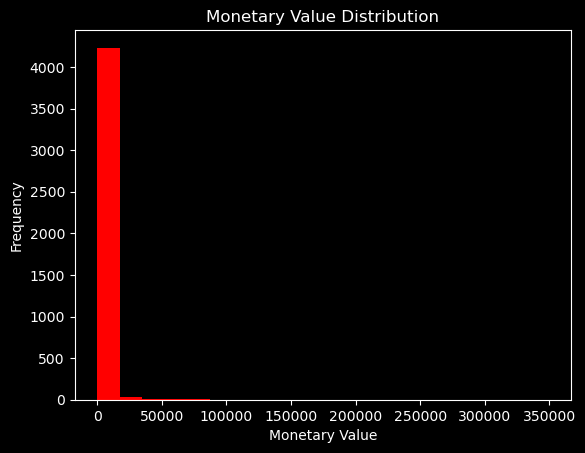

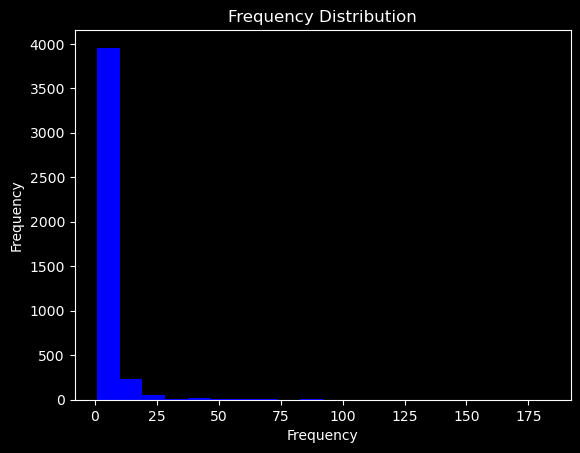

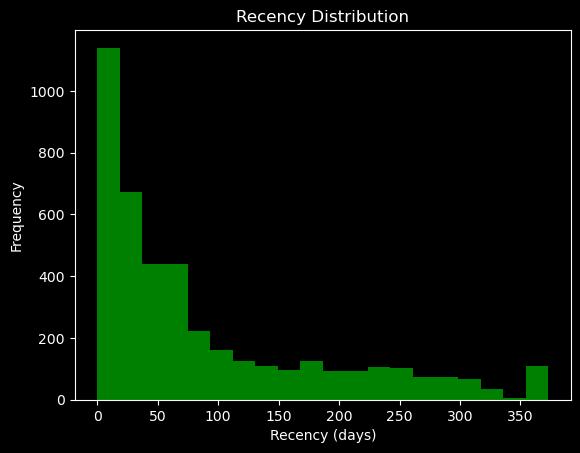

In [26]:
plt.hist(agreggated_df['MonetaryValue'], bins=20, color='red')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')
plt.show()

plt.hist(agreggated_df['Frequency'], bins=20, color='blue')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Frequency')
plt.show()

plt.hist(agreggated_df['Recency'], bins=20, color='green')
plt.title('Recency Distribution')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency')
plt.show()

Based on the histogram, the data in monetary value and frequency are highly skewed. Data from recency is acceptable.

Further outlier detection using boxplots:

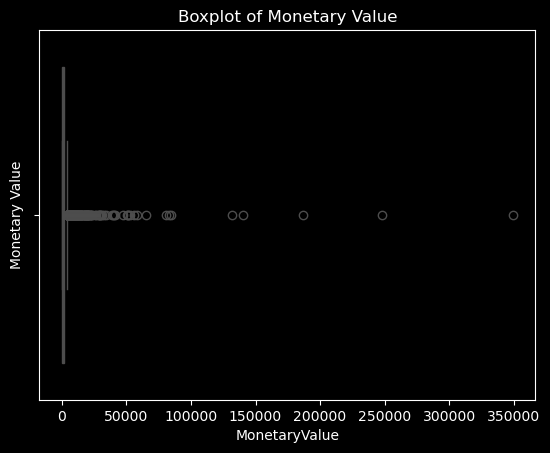

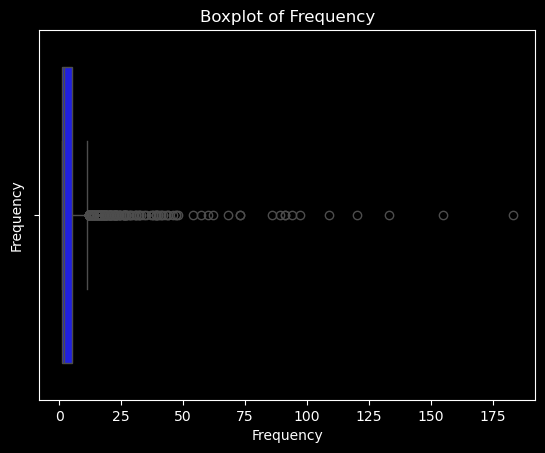

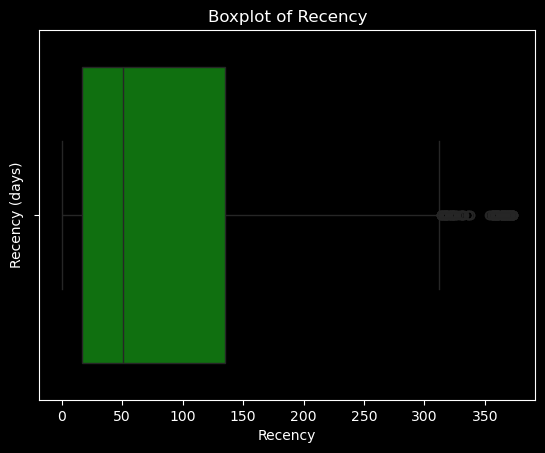

In [27]:
sns.boxplot(x=agreggated_df['MonetaryValue'], color='red')
plt.title('Boxplot of Monetary Value')
plt.ylabel('Monetary Value')
plt.show()

sns.boxplot(x=agreggated_df['Frequency'], color='blue')
plt.title('Boxplot of Frequency')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=agreggated_df['Recency'], color='green')
plt.title('Boxplot of Recency')
plt.ylabel('Recency (days)')
plt.show()

As observed, there are a high number of outliers for each feature, so for a more complete and realistic analysis, outliers in the data will be sepparated and analyzed separately. This separation is done using IQR.

In [28]:
# Outlier filtering for monetary value
M_Q1 = agreggated_df['MonetaryValue'].quantile(0.25)
M_Q3 = agreggated_df['MonetaryValue'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

M_outlier_df = agreggated_df[(agreggated_df['MonetaryValue'] < (M_Q1 - 1.5 * M_IQR)) | 
                          (agreggated_df['MonetaryValue'] > (M_Q3 + 1.5 * M_IQR))].copy()

# Outlier filtering for frequency
F_Q1 = agreggated_df['Frequency'].quantile(0.25)
F_Q3 = agreggated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1

F_outlier_df = agreggated_df[(agreggated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR)) | 
                          (agreggated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR))].copy()



In [29]:
print("\nOutliers in Monetary Value:")
M_outlier_df.describe()


Outliers in Monetary Value:


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723328,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


In [30]:
print("\nOutliers in Frequency:")
F_outlier_df.describe()


Outliers in Frequency:


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161216,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


Note: monetary outliers and frequency outliers dfs might have overlaps, as the share data, creating high monetary value outliers, high frequency outliers, and high monetary value and frequency outliers.

Create a new df without outliers:

In [ ]:
# Keeping data where the index values of agreggated_df are not in the index of M_outlier_df and F_outlier_df to avoid overlaps.
non_outlier_df = agreggated_df[
    (~agreggated_df.index.isin(M_outlier_df.index)) & 
    (~agreggated_df.index.isin(F_outlier_df.index))]

print("\nNon-outlier DataFrame Description:")
non_outlier_df.describe()


Non-outlier DataFrame Description:


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


Valiate the df with histograms and boxplots:

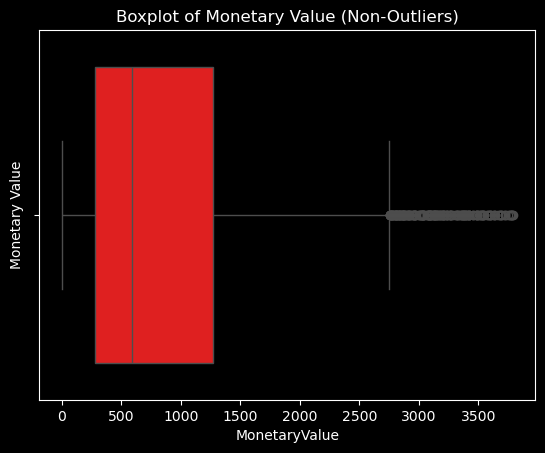

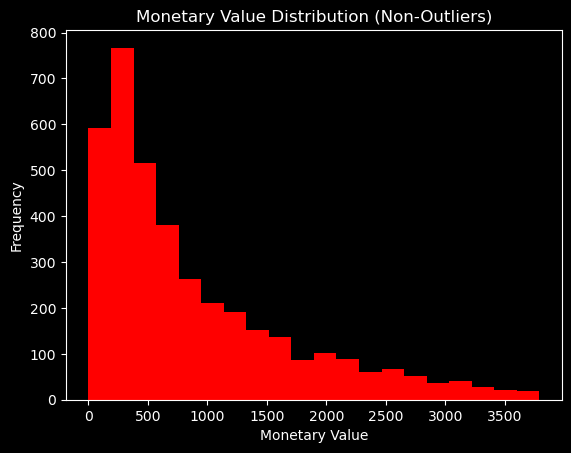

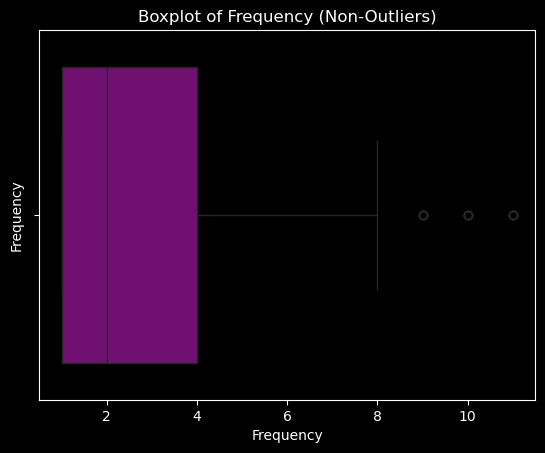

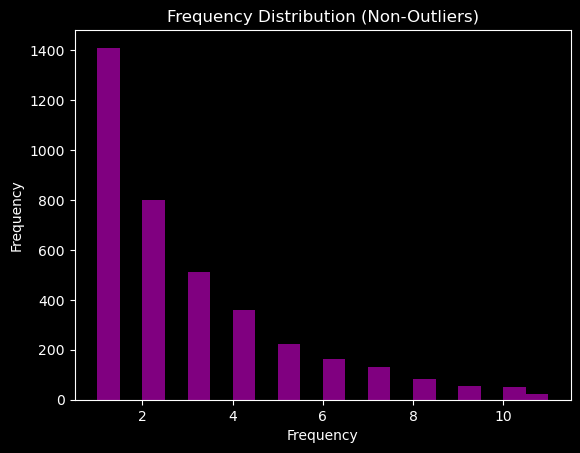

In [32]:
sns.boxplot(x=non_outlier_df['MonetaryValue'], color='red')
plt.title('Boxplot of Monetary Value (Non-Outliers)')
plt.ylabel('Monetary Value')
plt.show()

plt.hist(non_outlier_df['MonetaryValue'], bins=20, color='red')
plt.title('Monetary Value Distribution (Non-Outliers)')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x=non_outlier_df['Frequency'], color='purple')
plt.title('Boxplot of Frequency (Non-Outliers)')
plt.ylabel('Frequency')
plt.show()

plt.hist(non_outlier_df['Frequency'], bins=20, color='purple')
plt.title('Frequency Distribution (Non-Outliers)')
plt.xlabel('Frequency')
plt.ylabel('Frequency')
plt.show()

Although there are still otuliers in the data, these are tolerable as their number has been reduced and the distributions are better, so the analysis can continue.

Plotting recency, monetary value and frequency in 3D to further analyze:

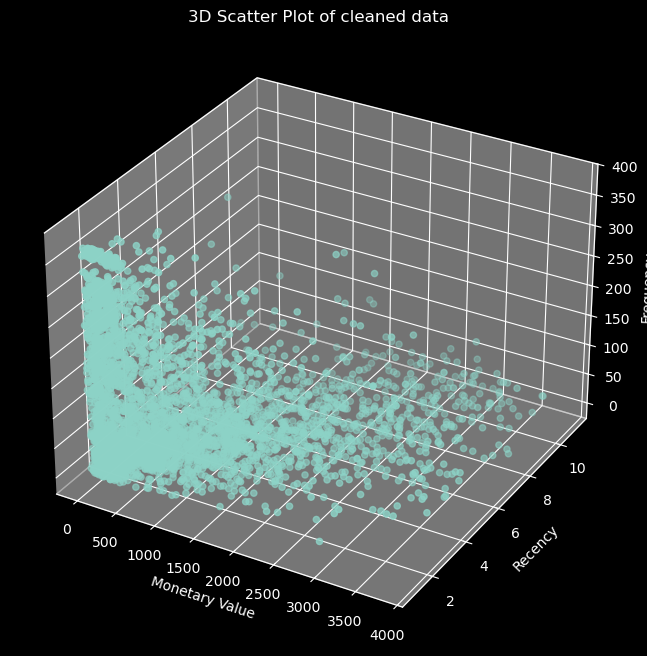

In [33]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outlier_df['MonetaryValue'],non_outlier_df['Frequency'], non_outlier_df['Recency'])
plt.title('3D Scatter Plot of cleaned data')
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Recency')
ax.set_zlabel('Frequency')
plt.show()

To further prepare the data, scaling is needed so each feature is on the same scale. In this case, standard scaling is used. Although the data is not a normal distribution, it is close enough to use standard scaling. An alternative could be by scaling using methods such as Box-Cox.

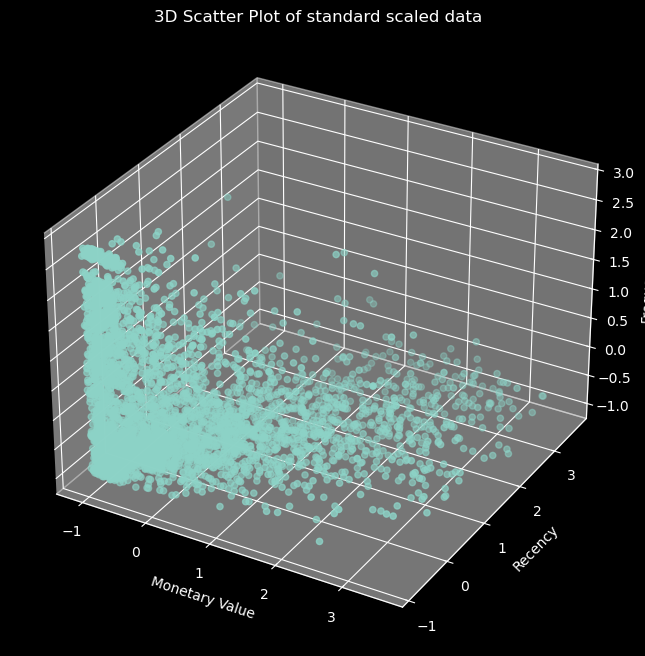

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outlier_df[['MonetaryValue', 'Frequency', 'Recency']])

# Transform the scaled data back to a DataFrame and keep the original index and column names from non_outlier_df
scaled_data_df = pd.DataFrame(scaled_data,index=non_outlier_df.index ,columns=['MonetaryValue', 'Frequency', 'Recency'])

# Re plotting the 3D scatter plot with scaled data
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(scaled_data_df['MonetaryValue'],scaled_data_df['Frequency'], scaled_data_df['Recency'])
plt.title('3D Scatter Plot of standard scaled data')
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Recency')
ax.set_zlabel('Frequency')
plt.show()

As observed, the features are now within the same scale.

Kmeans clustering

Determine the value of K based on the elbow method:

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

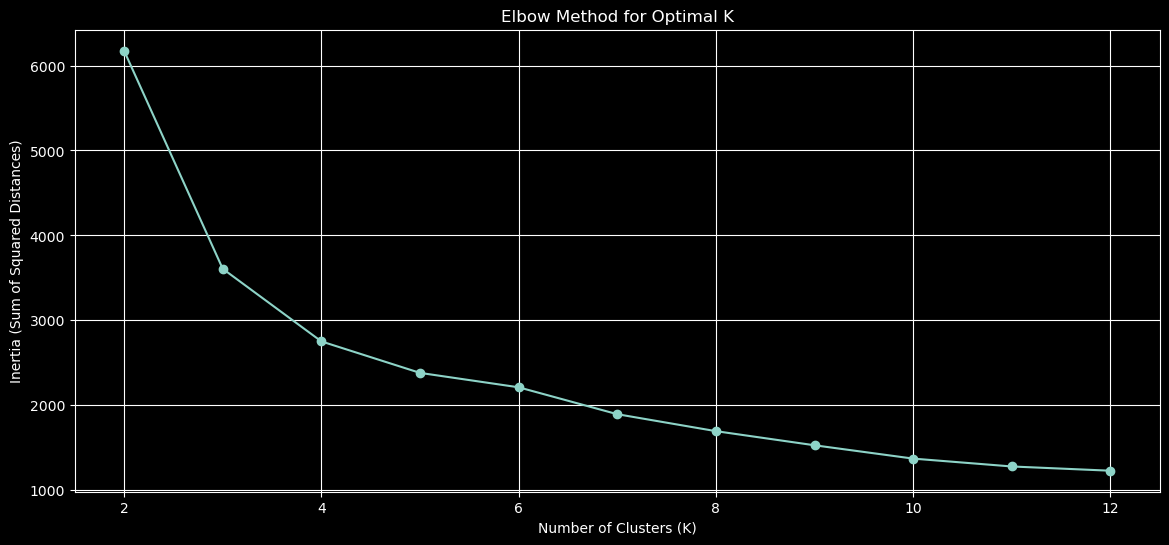

In [ ]:
max_k = 12
inertia = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init='auto')
    kmeans.fit_predict(scaled_data_df)
    
    inertia.append(kmeans.inertia_)
    
# Elbow method plot
plt.figure(figsize=(14,6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

Alongside the elbow graph, the silhouette score can be used to determine the optimal number of K.
A high score means that clusters are not overlapping, so it is preferable.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

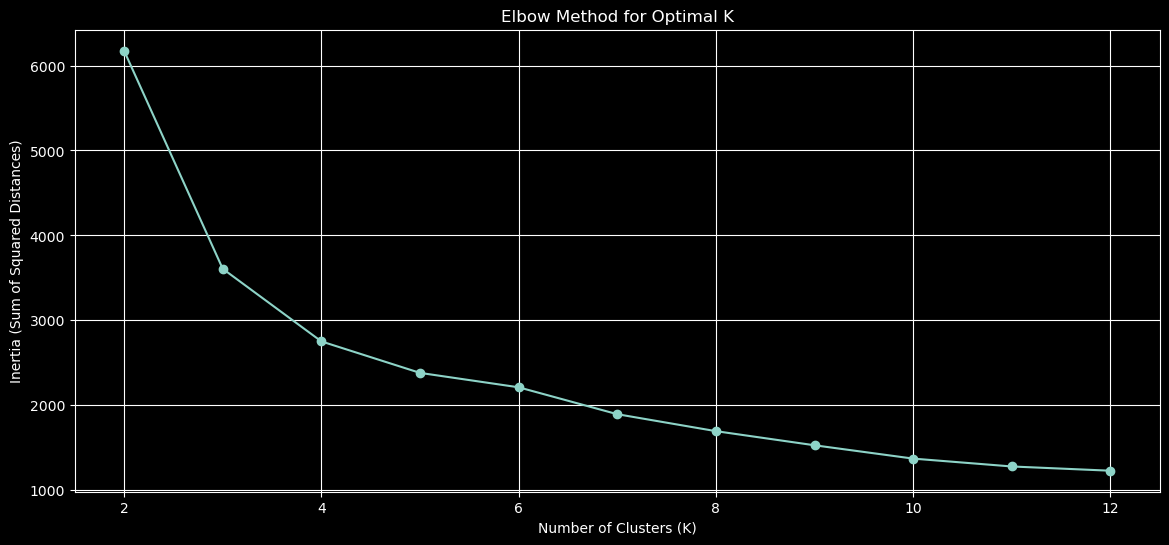

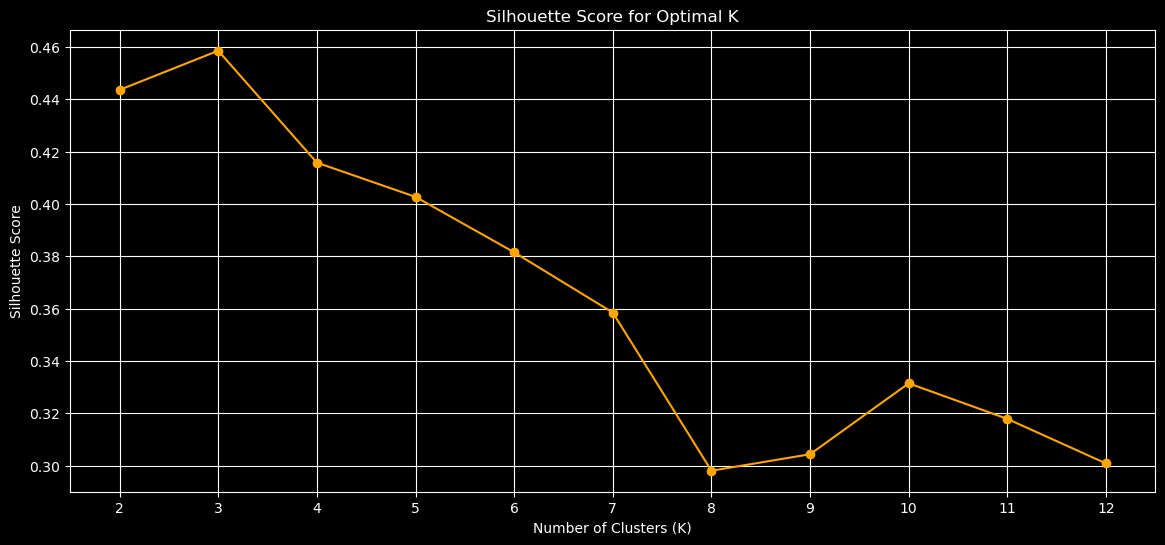

In [ ]:
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_data_df)
    
    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    
    silhouette_scores.append(sil_score)
    
    inertia.append(kmeans.inertia_)
    
# Elbow method plot
plt.figure(figsize=(14,6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

# Silhouette score plot
plt.figure(figsize=(14,6))
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Based on the graphs, a value of K = 4 is assumed, as greater values of k don't have a significant impact and can lead to unnecesary clusters.

Model

In [38]:
Kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000, n_init='auto')
cluster_labels = Kmeans.fit_predict(scaled_data_df)
cluster_labels

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=15.
  warnings.warn(


array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

Add cluster labels to the data

In [39]:
non_outlier_df['Cluster'] = cluster_labels
non_outlier_df

C:\Users\diego\AppData\Local\Temp\ipykernel_23748\1807462742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['Cluster'] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,0


Visualizing data with the cluster labels

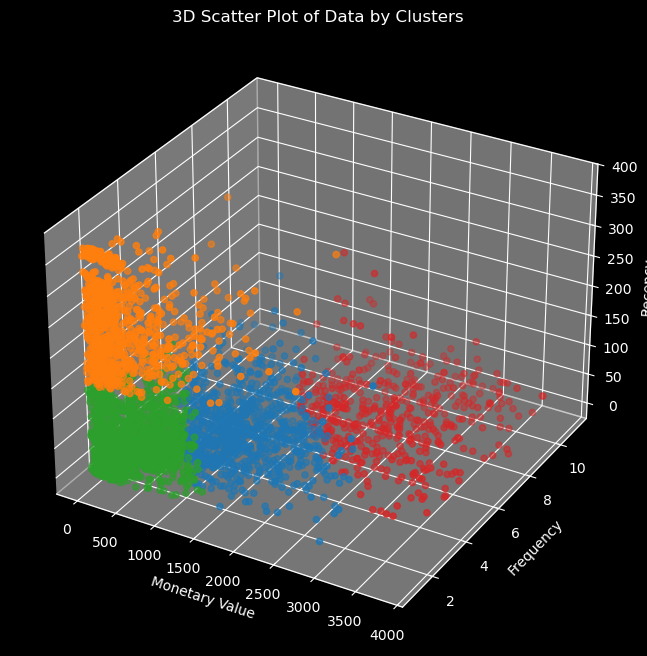

In [ ]:
# Adding colors to each cluster for better identification
cluster_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728'}
colors = non_outlier_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

# Create a 3D plot of the clustered data
scatter = ax.scatter(non_outlier_df['MonetaryValue'], 
                     non_outlier_df['Frequency'], 
                     non_outlier_df['Recency'],
                     c=colors, 
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Data by Clusters')
plt.show()

Interpreting the clusters using violin plots

Every feature has a violin plot for each cluster of data, as well as a violin plot with the full data (not clustered)

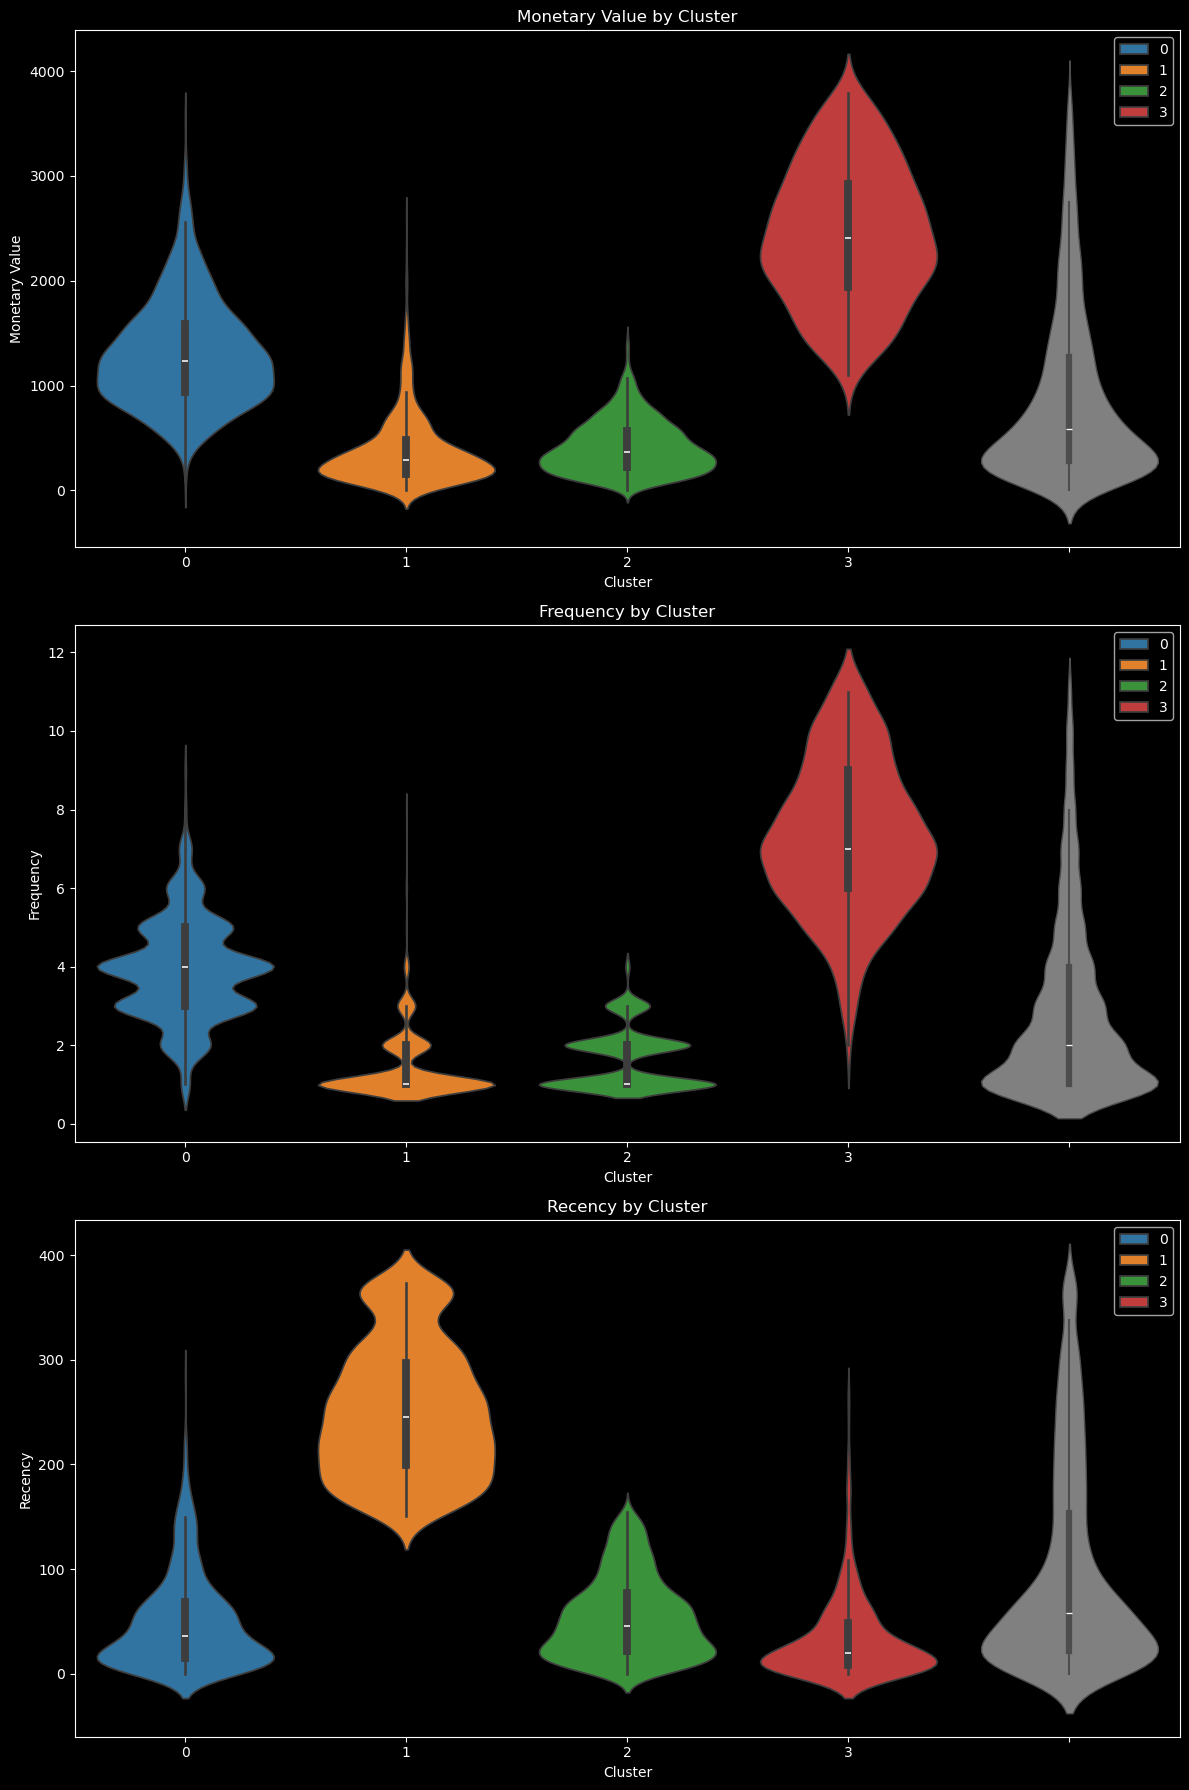

In [45]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['MonetaryValue'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['Frequency'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outlier_df['Cluster'], y=non_outlier_df['Recency'], palette=cluster_colors, hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

Cluster analysis

1) Cluster 0 (Blue)
These group has higher than usual monetary value and frequency, but recency appears to be lower than usual.
It can be interpreted as high value customers as their spent is above average and they purchase regularly, although not always recently. 

Suggested actions are to maintain their loyalty and spending levels with loyalty programs, personalized offers, and engagement to ensure they remain active customers.

2) Cluster 1 (Yellow)
These group includes low value infrequent customes that haven't made purchases recently. Re-enganement is needed to have an active purchasing behaviour.

Suggested actions are to use targeted marketing campaings, implement reminders, and offer discounts for them to return.

3) Cluster 2 (Green)
These group includes customers with low value purchases and low frequency, but they have made recent purchases. These customers need to increase their spending and engagement.

Suggested actions are to provide customer service and offer incentives  to encourage further purchases, as well as an increased purchase frequency.

4) Cluster 3 (Red)
These group contains high value customers with high value purchases and high frequency and recency, being the most loyal and valuable customers. The focus should be on maintaining these loyalty.

Suggested actions are to implement loyalty and rewards programs, exclusive offers, and recognize their loyalty to retain them.

Summary of cluster designations:
* Cluster 0 (Blue): Retain
* Cluster 1 (Yellow): Revive
* Cluster 2 (Green): Nurture
* Cluster 3 (Red): Reward

Oultier analysis

Form 3 new clusters with the outliers, taking into consideration the overlap between otuliers in monetary value and frequency.

In [46]:
# Find overlapping indexes between monetary value and frequency outliers dataframes
overlap_indices = M_outlier_df.index.intersection(F_outlier_df.index)

# Filtering out the outliers into three separate dataframes
# Monetary value only outliers
M_only_outliers = M_outlier_df.drop(overlap_indices)

# Frequency only outliers
F_only_outliers = F_outlier_df.drop(overlap_indices)

# Monetary value and frequency overlapping outliers
M_and_F_outliers = M_outlier_df.loc[overlap_indices]

# Cluster labels. Using negative numbers to specify that there were added manually
M_only_outliers['Cluster'] = -1
F_only_outliers['Cluster'] = -2
M_and_F_outliers['Cluster'] = -3

# Union of the three outlier dataframes into a single dataframe
outlier_clusters_df = pd.concat([M_only_outliers, F_only_outliers, M_and_F_outliers])
outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.00,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.00,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.00,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.00,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.00,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


Plotting the outliers with violin plots to analyze the outlier clusters:

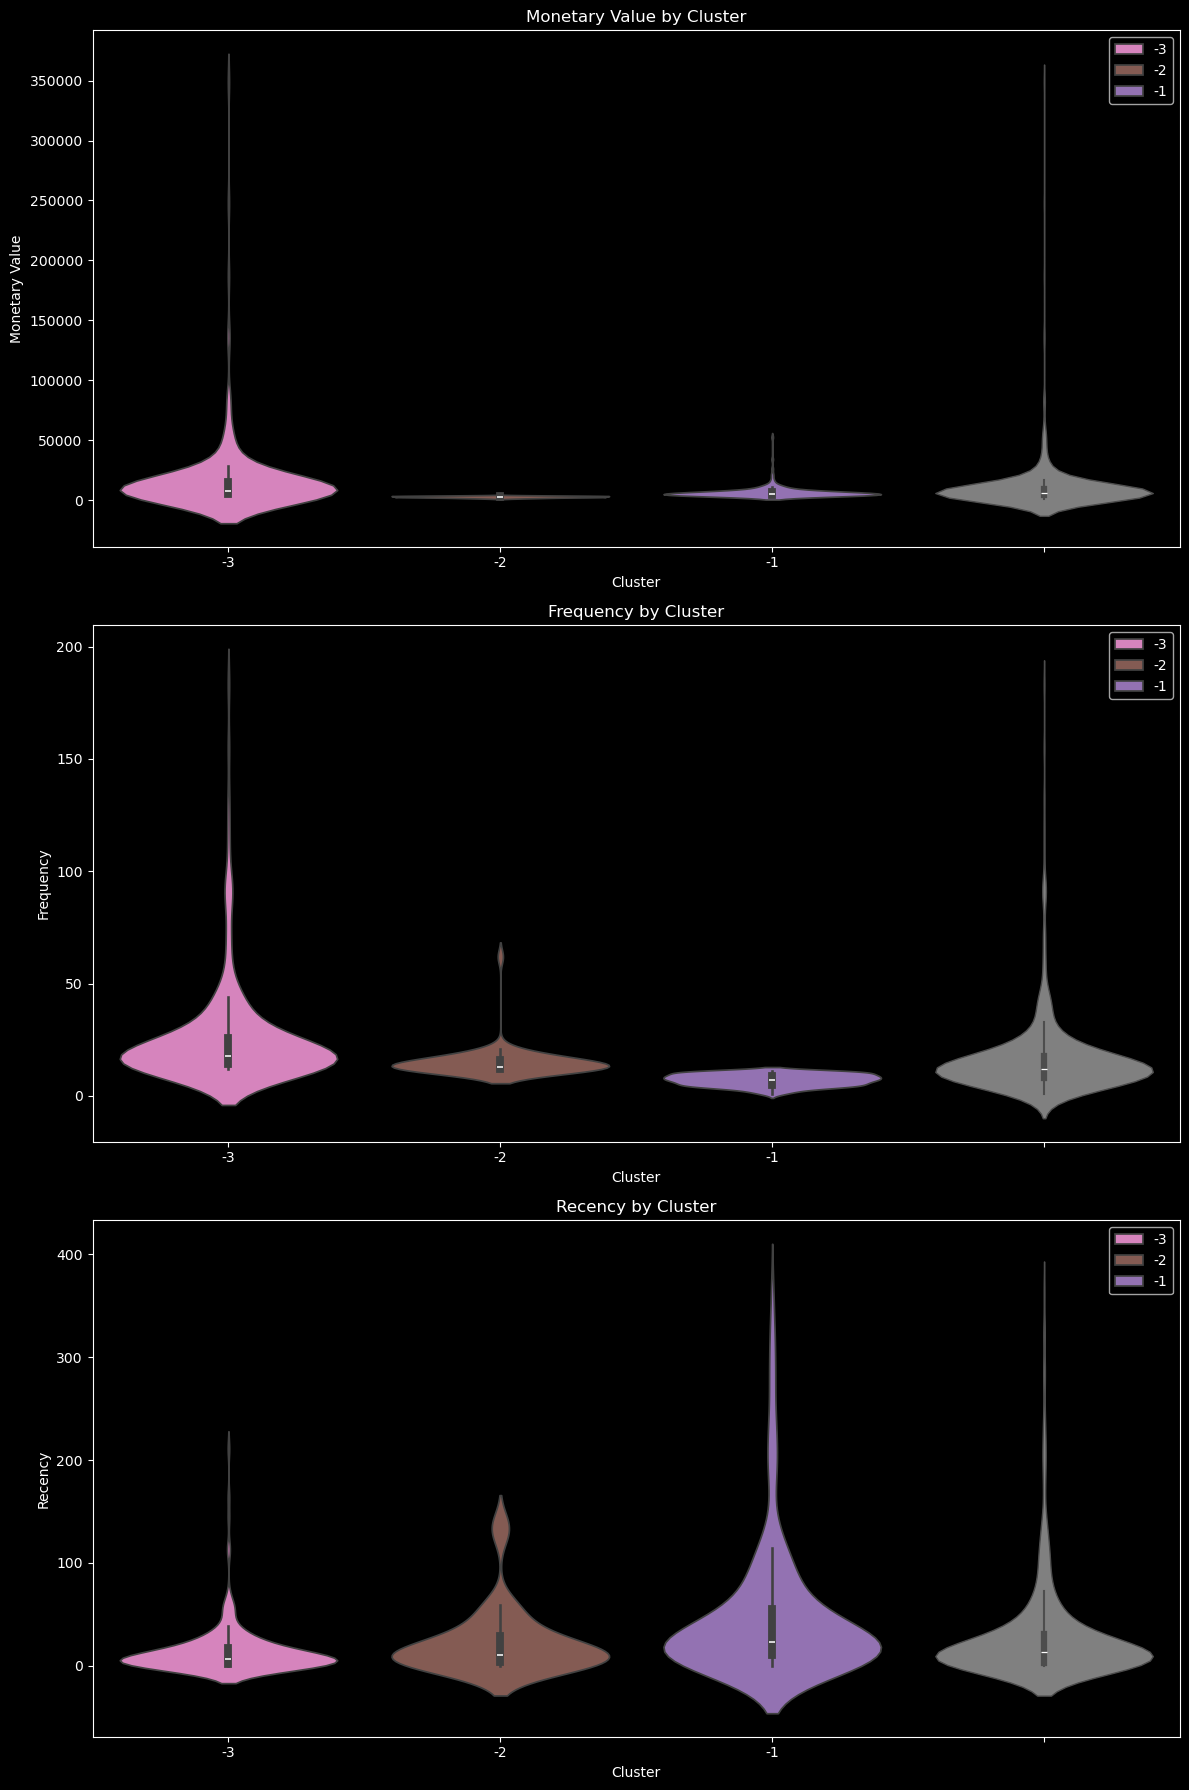

In [49]:
cluster_colors = {-1: '#9467bd', -2: '#8c564b', -3: '#e377c2'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df['Cluster'])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

Oultier data cluster analysis

1) Cluster -3 (Pink)
This cluster consists of mostly clients with some high value purchases. They also have an above average frequency, and an average recency. The focus should be to maintain and reward these customers as they are high value VIP customers.

Suggested actions are to explore the potential of a VIP program with exclusive offers for this select group of customers and maintain their attention with top tier customer service and rewards. Also, targeting luxury items and services towards them is recomended.

Cluster -2 (Brown)
These group has frequen customers but they spend less per purchase than the other clusters. Although frequent, they might benefit from upselling and discounts.

Suggested actions are to incorporate them into loyalty programs and offer incentives such as discounts or offers to encourage higher value purchases.

Cluster -1 (Purple)
These cluster has an some average and above average purchases but the aren't frequent spenders. The focus should be to revive them or improve frequency, as well as maintaining loyalty.

Suggested actions are personalized offers and deals according to their high spending capacity, targeting them with more luxury items and services.

Summary of cluster designations
* Cluster -3 (Pink): VIP
* Cluster -2 (Brown): Upsell
* Cluster -1 (Purple): Delight

General summary of cluster labels

* Cluster -3 (Pink): VIP
* Cluster -2 (Brown): Upsell
* Cluster -1 (Purple): Delight
* Cluster 0 (Blue): Retain
* Cluster 1 (Yellow): Revive
* Cluster 2 (Green): Nurture
* Cluster 3 (Red): Reward

Adding the cluster labels to the data:

In [50]:
# Create dictionary with cluster labels
cluster_labels = {
    -3: 'VIP',
    -2: 'Upsell',
    -1: 'Delight',
    0: 'Retain',
    1: 'Revive',
    2: 'Nurture',
    3: 'Reward'
}

# Union of non-outlier and outlier dataframes

full_cluster_df = pd.concat([non_outlier_df, outlier_clusters_df])

full_cluster_df['Cluster Label'] = full_cluster_df['Cluster'].map(cluster_labels)

print("\nFull data:")
print(full_cluster_df)


Full data:
              Customer ID        MonetaryValue  Frequency     LastInvoiceDate  \
0                12346.00               169.36          2 2010-06-28 13:53:00   
1                12347.00              1323.32          2 2010-12-07 14:57:00   
2                12348.00               221.16          1 2010-09-27 14:59:00   
3                12349.00              2221.14          2 2010-10-28 08:23:00   
4                12351.00               300.93          1 2010-11-29 15:23:00   
...                   ...                  ...        ...                 ...   
4235             18223.00              7516.31         12 2010-11-17 12:20:00   
4236             18225.00              7545.14         15 2010-12-09 15:46:00   
4237             18226.00              6650.83         15 2010-11-26 15:51:00   
4241             18231.00              4791.80         23 2010-10-29 14:17:00   
4262             18260.00              7318.91         17 2010-11-30 12:25:00   

      Recency  

Visualize the final results

C:\Users\diego\AppData\Local\Temp\ipykernel_23748\831531650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='plasma')


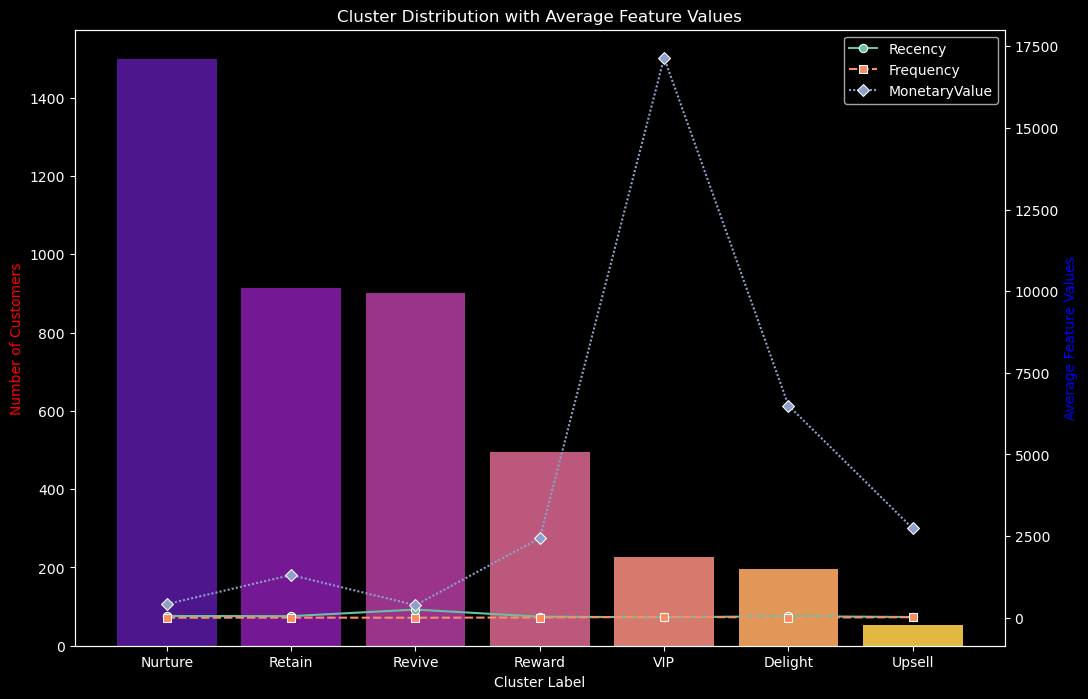

In [55]:
# Finding the number of values per cluster
cluster_counts = full_cluster_df['Cluster Label'].value_counts()

# Caculating the average values of the features per cluster
feature_means = full_cluster_df.groupby('Cluster Label')[['Recency', 'Frequency', 'MonetaryValue']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

# Bar plot to visualize the number of customers in each cluster
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='plasma')
ax1.set_title('Cluster Distribution with Average Feature Values')
ax1.set_ylabel('Number of Customers', color='red')

# Adding a second y-axis for the average feature values
ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', markers=['o','s','D'])
ax2.set_ylabel('Average Feature Values', color='blue')

plt.show()

Re-scaling the monetary value to better fit the data and visualize trends more clearly:

C:\Users\diego\AppData\Local\Temp\ipykernel_23748\779062670.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='plasma')


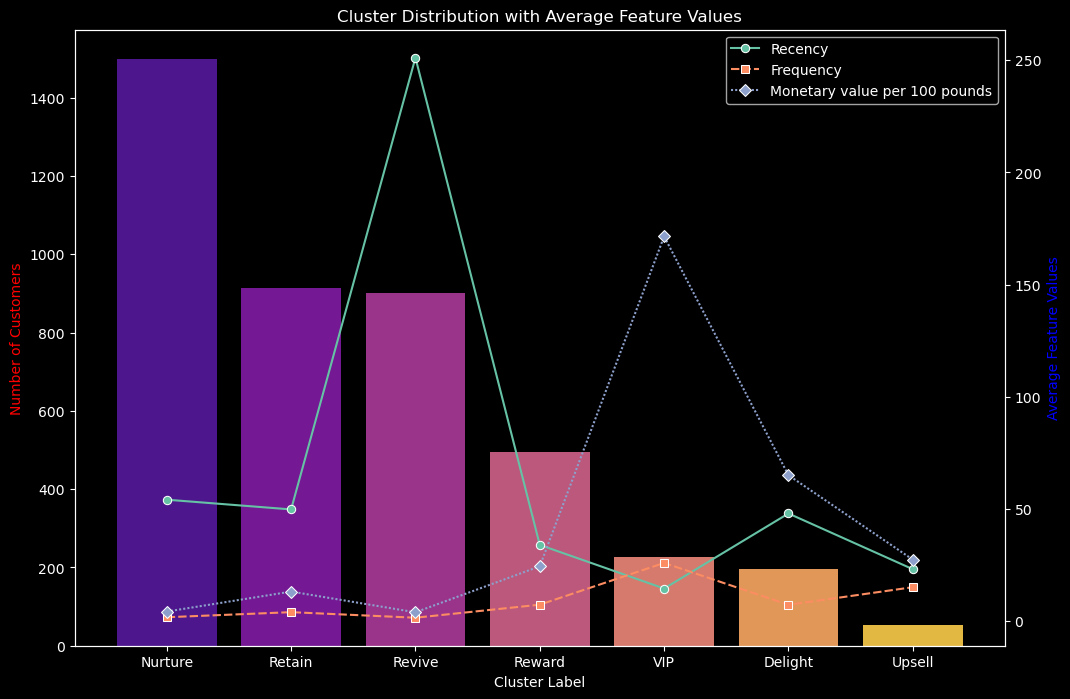

In [57]:
# Finding the number of values per cluster
cluster_counts = full_cluster_df['Cluster Label'].value_counts()
full_cluster_df['Monetary value per 100 pounds'] = full_cluster_df['MonetaryValue'] / 100
# Caculating the average values of the features per cluster
feature_means = full_cluster_df.groupby('Cluster Label')[['Recency', 'Frequency', 'Monetary value per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

# Bar plot to visualize the number of customers in each cluster
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='plasma')
ax1.set_title('Cluster Distribution with Average Feature Values')
ax1.set_ylabel('Number of Customers', color='red')

# Adding a second y-axis for the average feature values
ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', markers=['o','s','D'])
ax2.set_ylabel('Average Feature Values', color='blue')

plt.show()

Results interpretation

The order of priority recomended is:

1) Keep and maintain the nurture group, as losing this group would greatly impact the business due to ther size and contribution.

2) Focus action on improving the revive group to reduce it by engaging more with these customers.

3) Maintain the retain group customers happy by applying the suggested actions or other strategies to keep them.

4) Maintain and reward the high value customer groups (Reward, VIP and deligth) as they have a great monetary impact on the business.

5) Improve engagement and retention of the Upsell group, as efforts to improve relations with them will be fruitful.